# Refinery Gasoline Blending: Nonlinear Pool vs. Linear LP with Back-off

A refinery makes its margin in the blender. Component streams (straight-run
naphtha, reformate, FCC gasoline, alkylate, butane) are mixed into a finished
gasoline whose *properties* must meet specifications: research and motor octane
(RON, MON), Reid vapor pressure (RVP) and sulfur.

A planning LP blends those properties **linearly by volume**, sometimes through a
blending index, and protects itself with a **back-off**. The real blend is
nonlinear. Octane numbers interact, and `difflow_refinery.BlendPool` uses the Ethyl
RT-70 interaction model for them. This notebook:

1. builds the components from a crude, cut into fractions (the CDU side);
2. blends them in a `BlendPool` and inspects properties, margins and gradients;
3. solves the **linear-by-volume LP** a planner would. Its plan is off spec in the
   rigorous model;
4. runs **successive back-off**: tighten each LP row by `BlendPool.backoff` at the
   current plan and re-solve, until the plan stops moving;
5. optimizes the recipe **directly on the nonlinear pool** (SLSQP with exact JAX
   gradients, multistart) and compares.

**About the "CDU" here.** `difflow_refinery` does not have a crude column yet
(the CDU and VDU are separate issues). The crude is cut by an *ideal TBP split*:
a logistic in boiling point at each cut point. That is enough to give the pool
realistic pseudocomponent streams to blend. Swap in a rigorous column when one
exists; nothing downstream changes, because the pool only sees streams.

## 1. Setup: a pseudocomponent grid and a crude

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

jax.config.update("jax_enable_x64", True)

from difflow.streams import make_stream
from difflow_refinery import BlendComponent, BlendPool, Characterization

BBL = 0.158987294928               # m^3 per barrel
KBD = 1000 * BBL / 86400.0         # m^3/s per thousand barrels/day

# n-butane (a defined component: its own critical constants) plus 24
# pseudocomponents from 300 K to 780 K normal boiling point.
npc = 24
Tb = np.linspace(300.0, 780.0, npc)
SG = 0.62 + 0.36 * ((Tb - 300.0) / 480.0) ** 0.8
nan = float("nan")
char = Characterization(
    names=["nC4"] + [f"pc{int(t)}" for t in Tb],
    Tb=[272.66] + list(Tb), SG=[0.584] + list(SG),
    MW=[58.12] + [nan] * npc, Tc=[425.12] + [nan] * npc,
    Pc=[37.96e5] + [nan] * npc, omega=[0.200] + [nan] * npc,
    qualities={
        "S_ppm": [0.0] + list(20.0 * np.exp((Tb - 300.0) / 80.0)),
        "olefins_vol": [0.0] * (npc + 1),
        "aromatics_vol": [0.0] + list(np.linspace(3.0, 25.0, npc)),
    })

# 100 kbbl/d of crude: a broad boiling distribution plus 1.5 vol% butane
w = np.exp(-0.5 * ((Tb - 560.0) / 150.0) ** 2)
vol_frac = np.concatenate([[0.015], 0.985 * w / w.sum()])
crude_moles = 100 * KBD * vol_frac / np.asarray(char.molar_volume)
crude = make_stream(dict(zip(char.names, crude_moles)), T=298.0, P=2e5)
print(f"crude: {len(char.names)} species, MW {float(char.mw[1]):.0f}-{float(char.mw[-1]):.0f} g/mol")

crude: 25 species, MW 74-381 g/mol


## 2. The crude unit stand-in: ideal TBP cuts

Each cut point $T_c$ splits every pseudocomponent with the logistic
$\sigma((T_b - T_c)/s)$, so the cut yields are smooth in the cut points.

In [2]:
def ideal_cuts(stream, cut_points, sharpness=6.0):
    # Ideal TBP split of `stream` at `cut_points` (K). NOT a column.
    F, tb = char.flows(stream), char.Tb
    above = [jax.nn.sigmoid((tb - c) / sharpness) for c in cut_points]
    out, prev = [], jnp.ones_like(tb)
    for a in above:
        out.append(F * (prev - a))
        prev = a
    out.append(F * prev)
    return [make_stream(dict(zip(char.names, f)), T=stream["T"], P=stream["P"])
            for f in out]

def as_stream(moles, T=310.0, P=2e5):
    return make_stream(dict(zip(char.names, moles)), T=T, P=P)

lpg, lsr, hsr, kero, resid = ideal_cuts(crude, [290.0, 355.0, 450.0, 540.0])
for name, s in [("LPG", lpg), ("LSR naphtha", lsr), ("HSR naphtha", hsr),
                ("kerosene", kero), ("atm. residue", resid)]:
    V = float(jnp.sum(char.flows(s) * char.molar_volume)) / KBD
    print(f"{name:14s} {V:6.2f} kbbl/d")

LPG              1.65 kbbl/d
LSR naphtha      5.38 kbbl/d
HSR naphtha     16.00 kbbl/d
kerosene        23.40 kbbl/d
atm. residue    53.58 kbbl/d


## 3. Blend components

Each component is built **from its stream**: `SG`, sulfur, aromatics and a Raoult
RVP come from the pseudocomponent composition. A conversion unit reports its own
octane and composition, so those properties are given as **overrides**:

* **LSR naphtha**: the crude cut, with a straight-run RON/MON.
* **Reformate**: the HSR cut after reforming (85 vol% liquid yield). The
  reformer is not modelled, so its octane and aromatics are what it reports.
* **FCC gasoline, alkylate**: bought-in or upstream streams with a
  naphtha-range composition.
* **n-butane**: pure; its 52 psi RVP is what makes it the cheap octane-neutral RVP
  filler.

In [3]:
def naphtha(weights, kbd):
    phi = np.zeros(npc + 1)
    phi[1:1 + len(weights)] = weights
    phi /= phi.sum()
    return as_stream(kbd * KBD * phi / np.asarray(char.molar_volume))

butane = np.zeros(npc + 1); butane[0] = 1.0
components = [
    BlendComponent.from_stream("LSR", lsr, char, RON=68.0, MON=66.0),
    BlendComponent.from_stream("reformate", as_stream(0.85 * char.flows(hsr)), char,
                               RON=98.0, MON=88.0, aromatics_vol=65.0,
                               olefins_vol=1.0, S_ppm=0.5),
    BlendComponent.from_stream("FCC", naphtha([0, 1, 2, 3, 3, 2, 1.5, 1], 25.0), char,
                               RON=92.5, MON=80.5, olefins_vol=28.0,
                               aromatics_vol=24.0, S_ppm=25.0),
    BlendComponent.from_stream("alkylate", naphtha([1, 3, 4, 2, 1], 10.0), char,
                               RON=96.0, MON=93.5, olefins_vol=0.5,
                               aromatics_vol=0.5, S_ppm=5.0),
    BlendComponent.from_stream("butane", as_stream(8 * KBD * butane / float(char.molar_volume[0]), T=300.0, P=6e5),
                               char, RON=93.8, MON=89.6),
]
names = [c.name for c in components]
avail = np.array([float(c.available_volume) / KBD for c in components])
cost = np.array([60.0, 82.0, 80.0, 92.0, 45.0])   # $/bbl
price = 95.0                                     # $/bbl finished gasoline

print(f"{'':10s}{'kbbl/d':>8s}{'$/bbl':>7s}{'SG':>7s}{'RON':>6s}{'MON':>6s}{'RVP':>7s}{'S ppm':>7s}{'arom':>6s}{'olef':>6s}")
for c, a, k in zip(components, avail, cost):
    p = {key: float(v) for key, v in c.properties.items()}
    print(f"{c.name:10s}{a:8.2f}{k:7.0f}{p['SG']:7.3f}{p['RON']:6.1f}{p['MON']:6.1f}"
          f"{p['RVP_psi']:7.2f}{p['S_ppm']:7.1f}{p['aromatics_vol']:6.1f}{p['olefins_vol']:6.1f}")

            kbbl/d  $/bbl     SG   RON   MON    RVP  S ppm  arom  olef
LSR           5.38     60  0.654  68.0  66.0  10.76   29.3   4.2   0.0
reformate    13.60     82  0.729  98.0  88.0   0.78    0.5  65.0   1.0
FCC          25.00     80  0.705  92.5  80.5   2.57   25.0  24.0  28.0
alkylate     10.00     92  0.667  96.0  93.5   7.28    5.0   0.5   0.5
butane        8.00     45  0.584  93.8  89.6  51.85    0.0   0.0   0.0


## 4. One blend: properties, margins, and what a linear blend gets wrong

The pool reports the blended properties, the composition-derived ones (TBP
evaporated at 70/100 °C, D86 points, a Raoult RVP on the blend's own
pseudocomponents as a check on the index), and a signed margin per spec.

In [4]:
pool = BlendPool("gasoline", specs=[("RON", ">=", 91.0), ("MON", ">=", 82.0),
                                    ("RVP_psi", "<=", 9.0), ("S_ppm", "<=", 10.0)])
recipe = np.array([2.0, 8.0, 10.0, 5.0, 2.0])     # kbbl/d
res = pool(components, recipe * KBD, basis="volume_flow")
lin = pool.linear_properties(components, recipe * KBD, basis="volume_flow")
print(f"{'property':16s}{'nonlinear':>11s}{'linear/vol':>12s}")
for k, v in res.properties.items():
    print(f"{k:16s}{float(v):11.3f}{float(lin.get(k, jnp.nan)):12.3f}")
print()
for k, m in res.margins.items():
    print(f"margin  {k:14s}{float(m):+8.3f}")

property          nonlinear  linear/vol
SG                    0.692       0.692
S_ppm                12.529      12.507
aromatics_vol        28.555      28.555
olefins_vol          10.759      10.759
RON                  93.559      93.059
MON                  80.264      84.730
RVP_psi               8.904       7.166
AKI                  86.912      88.894
density_kgm3        691.737     691.737
E70_tbp              29.769      29.769
E100_tbp             52.155      52.155
T10_d86_C            51.129      77.762
T50_d86_C            96.631      95.847
T90_d86_C           151.611     127.375
RVP_raoult_psi        8.754       7.166

margin  RON >= 91       +2.559
margin  MON >= 82       -1.736
margin  RVP_psi <= 9    +0.096
margin  S_ppm <= 10     -2.529


RVP blends through the $\mathrm{RVP}^{1.25}$ index in both the pool and the LP below,
and sulfur blends by mass in both. Neither is a source of LP error here. Octane is.
RON blends slightly *above* its linear value (the sensitivity interaction).
MON blends well *below* it: the olefin×MON interaction and the aromatic-spread
term both pull it down, and a reformate/FCC pool has spread in both.

The pool is differentiable in the recipe and in every component property.
Here is the MON sensitivity, checked against central differences:

In [5]:
mon = lambda r: pool(components, r * KBD, basis="volume_flow").properties["MON"]
g = jax.grad(mon)(jnp.asarray(recipe))
h = 1e-5
fd = [(mon(recipe + h * e) - mon(recipe - h * e)) / (2 * h) for e in np.eye(5)]
for n, a, b in zip(names, g, fd):
    print(f"dMON/dV[{n:9s}] = {float(a):+.6f} /kbbl/d   (FD {float(b):+.6f})")

dMON/dV[LSR      ] = -0.275228 /kbbl/d   (FD -0.275228)
dMON/dV[reformate] = -0.075150 /kbbl/d   (FD -0.075150)
dMON/dV[FCC      ] = -0.007687 /kbbl/d   (FD -0.007687)
dMON/dV[alkylate ] = +0.201505 /kbbl/d   (FD +0.201505)
dMON/dV[butane   ] = +0.110501 /kbbl/d   (FD +0.110501)


## 5. The planner's LP, and why it needs a back-off

The LP's blending rows are linear in the volumes:

* $\sum_i V_i(\mathrm{RON}_i - 91 - b_\mathrm{RON}) \ge 0$, and the same for MON (linear by volume);
* $\sum_i V_i(\mathrm{RVP}_i^{1.25} - (9 - b_\mathrm{RVP})^{1.25}) \le 0$ (the RVP index);
* $\sum_i V_i\,\mathrm{SG}_i(S_i - 10 + b_S) \le 0$ (sulfur by mass).

With no back-off ($b = 0$) the LP's plan looks feasible to the LP and is not.

In [6]:
unit_margin = price - cost

def profit(x):
    return float(unit_margin @ x)

P = {k: np.array([float(c.properties[k]) for c in components])
     for k in ["RON", "MON", "RVP_psi", "S_ppm", "SG"]}
spec_names = [s.name for s in pool.specs]

def solve_lp(b):
    A = [-(P["RON"] - (91.0 + b["RON >= 91"])),
         -(P["MON"] - (82.0 + b["MON >= 82"])),
         P["RVP_psi"] ** 1.25 - (9.0 - b["RVP_psi <= 9"]) ** 1.25,
         P["SG"] * (P["S_ppm"] - (10.0 - b["S_ppm <= 10"]))]
    r = linprog(-unit_margin, A_ub=np.array(A), b_ub=np.zeros(4),
                bounds=[(0.0, a) for a in avail])
    assert r.status == 0, r.message
    return r.x

def true_margins(x):
    return {k: float(v) for k, v in pool(components, x * KBD, basis="volume_flow").margins.items()}

x_lp = solve_lp(dict.fromkeys(spec_names, 0.0))
print(f"LP (no back-off): {profit(x_lp):.2f} k$/d -- true margins in the nonlinear pool:")
for k, m in true_margins(x_lp).items():
    print(f"  {k:14s}{m:+.4f}")

LP (no back-off): 622.65 k$/d -- true margins in the nonlinear pool:


  RON >= 91     +1.7243
  MON >= 82     -2.0323
  RVP_psi <= 9  -0.0000
  S_ppm <= 10   +0.0000


### Successive back-off

`BlendPool.backoff(..., exact=("RVP_psi", "S_ppm"))` returns, per spec, how far
the LP's linear view overstates the margin at a recipe. RVP and sulfur are
declared `exact` because the LP already models them with the pool's own rule.
Tighten the rows by that amount, re-solve, and repeat until the plan stops moving.

In [7]:
history = []
x = x_lp
for it in range(15):
    b = {k: float(v) for k, v in pool.backoff(components, x * KBD, basis="volume_flow",
                                                exact=("RVP_psi", "S_ppm")).items()}
    x_new = solve_lp(b)
    tm = true_margins(x_new)
    history.append((it, b["MON >= 82"], profit(x_new), tm["MON >= 82"]))
    print(f"pass {it:2d}: MON back-off {b['MON >= 82']:.4f}  profit {profit(x_new):8.3f}  "
          f"true MON margin {tm['MON >= 82']:+.5f}")
    if np.max(np.abs(x_new - x)) < 1e-6:
        break
    x = x_new
x_bo = x_new

pass  0: MON back-off 5.1233  profit  555.660  true MON margin -0.75559


pass  1: MON back-off 5.8789  profit  473.041  true MON margin -0.40143


pass  2: MON back-off 6.2803  profit  436.451  true MON margin -0.18042


pass  3: MON back-off 6.4607  profit  421.347  true MON margin -0.07328


pass  4: MON back-off 6.5340  profit  415.429  true MON margin -0.02834


...

pass 10: MON back-off 6.5794  profit  411.821  true MON margin -0.00008


pass 11: MON back-off 6.5795  profit  411.814  true MON margin -0.00003


pass 12: MON back-off 6.5795  profit  411.812  true MON margin -0.00001


pass 13: MON back-off 6.5795  profit  411.811  true MON margin -0.00000


pass 14: MON back-off 6.5795  profit  411.811  true MON margin -0.00000


## 6. The nonlinear optimum

Maximise the blending margin $\sum_i (p - c_i) V_i$ subject to every spec and to
availability, directly on the nonlinear pool. The spec margins are passed as
**volume-weighted** constraints (`weighted=True`), $V\,m(V) \ge 0$. A property is
intensive and 0/0 at an empty pool, and the weighted form is the same constraint
wherever $V > 0$.

Blending is nonconvex (the planning LP's docstring says as much: pooling and
blending stay bilinear), so this is a **local** search. We run SLSQP from a spread
of starts, including both LP plans, and keep every distinct feasible local optimum.

In [8]:
margins_w = jax.jit(lambda x: pool.spec_margins(components, x * KBD, basis="volume_flow",
                                                weighted=True) / KBD)
margins_jac = jax.jit(jax.jacobian(lambda x: pool.spec_margins(
    components, x * KBD, basis="volume_flow", weighted=True) / KBD))

def solve_nlp(x0):
    r = minimize(lambda x: -profit(x), x0, jac=lambda x: -unit_margin,
                 method="SLSQP", bounds=[(0.0, a) for a in avail],
                 constraints=[{"type": "ineq", "fun": lambda x: np.asarray(margins_w(x)),
                               "jac": lambda x: np.asarray(margins_jac(x))}],
                 options=dict(maxiter=500, ftol=1e-12))
    return r.x

rng = np.random.default_rng(0)
starts = [0.3 * avail, x_lp, x_bo] + [rng.uniform(0, 1, 5) * avail for _ in range(20)]
optima = {}
for x0 in starts:
    xx = solve_nlp(x0)
    if min(true_margins(xx).values()) > -1e-6:
        key = round(profit(xx), 2)
        optima.setdefault(key, [xx, 0])[1] += 1
for key in sorted(optima, reverse=True):
    xx, hits = optima[key]
    print(f"local optimum {key:8.2f} k$/d  (found from {hits:2d} of {len(starts)} starts)  "
          + "  ".join(f"{n}={v:.2f}" for n, v in zip(names, xx)))
x_nlp = optima[max(optima)][0]
x_first = solve_nlp(0.3 * avail)
print(f"\nSLSQP from the single default start lands on {profit(x_first):.2f} k$/d")

local optimum   411.81 k$/d  (found from  3 of 23 starts)  LSR=0.00  reformate=13.60  FCC=5.43  alkylate=10.00  butane=2.47
local optimum   381.01 k$/d  (found from 19 of 23 starts)  LSR=0.00  reformate=7.76  FCC=9.44  alkylate=10.00  butane=2.17

SLSQP from the single default start lands on 381.01 k$/d


## 7. Comparison

                       LSR reformate       FCC  alkylate    butane      k$/d  min margin


LP, no back-off      5.379    13.600     6.980    10.000     2.458    622.65     -2.0323


LP + back-off        0.000    13.600     5.427    10.000     2.472    411.81     -0.0000


NLP, one start       0.000     7.762     9.439    10.000     2.171    381.01     -0.0000


NLP, best            0.000    13.600     5.427    10.000     2.472    411.81     -0.0000

LP promise without back-off: +210.84 k$/d over the best feasible plan (51%), and off spec.
Converged back-off LP vs best NLP optimum: +0.0002 k$/d.


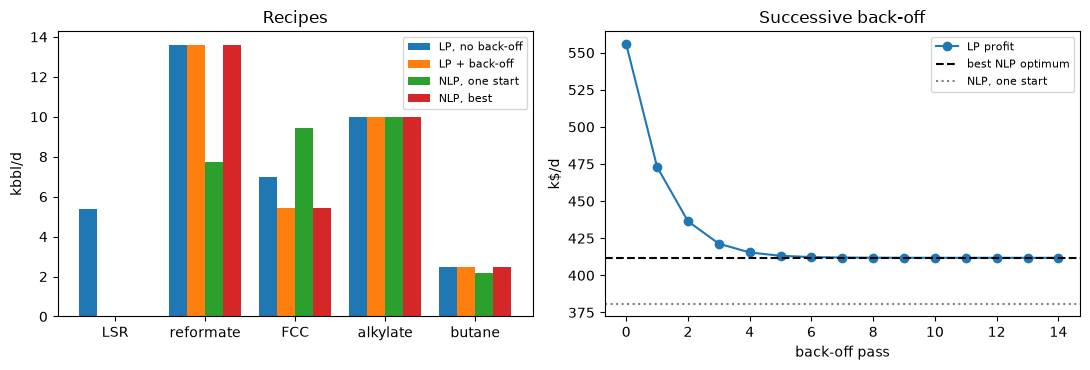

In [9]:
print(f"{'':16s}" + "".join(f"{n:>10s}" for n in names) + f"{'k$/d':>10s}{'min margin':>12s}")
for label, xx in [("LP, no back-off", x_lp), ("LP + back-off", x_bo),
                  ("NLP, one start", x_first), ("NLP, best", x_nlp)]:
    tm = true_margins(xx)
    print(f"{label:16s}" + "".join(f"{v:10.3f}" for v in xx) + f"{profit(xx):10.2f}{min(tm.values()):+12.4f}")
print(f"\nLP promise without back-off: {profit(x_lp) - profit(x_nlp):+.2f} k$/d over the best "
      f"feasible plan ({100 * (profit(x_lp) / profit(x_nlp) - 1):.0f}%), and off spec.")
print(f"Converged back-off LP vs best NLP optimum: {profit(x_bo) - profit(x_nlp):+.4f} k$/d.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
width = 0.27
idx = np.arange(len(names))
width = 0.2
for j, (label, xx) in enumerate([("LP, no back-off", x_lp), ("LP + back-off", x_bo),
                                 ("NLP, one start", x_first), ("NLP, best", x_nlp)]):
    ax[0].bar(idx + (j - 1.5) * width, xx, width, label=label)
ax[0].set_xticks(idx, names)
ax[0].set_ylabel("kbbl/d")
ax[0].set_title("Recipes")
ax[0].legend(fontsize=8)
its, bs, profits, mons = zip(*history)
ax[1].plot(its, profits, "o-", label="LP profit")
ax[1].axhline(profit(x_nlp), color="k", ls="--", label="best NLP optimum")
ax[1].axhline(profit(x_first), color="grey", ls=":", label="NLP, one start")
ax[1].set_xlabel("back-off pass")
ax[1].set_ylabel("k$/d")
ax[1].set_title("Successive back-off")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**What this shows** (on this pool; the numbers move with prices and components):

* **The unprotected LP over-promises, and its plan is off spec.** It reports a
  margin about half again larger than any feasible plan earns, and in the
  rigorous pool its recipe misses MON by about two numbers. Every unit of that
  error is octane interaction (`linear_blend_error`). RVP and sulfur are modelled
  exactly by the LP rows.
* **A one-shot back-off is not enough.** The back-off is a function of the recipe.
  The first pass, sized at the unprotected plan, still leaves the new plan off spec.
  It takes about a dozen passes to settle.
* **The converged back-off reaches the best nonlinear optimum here.** The
  multistart NLP finds several local optima. The best of them is the same vertex
  the back-off loop converges to (reformate and alkylate at availability, no
  straight-run). That is not guaranteed in general: the fixed point of successive
  back-off is a feasible vertex, not a certified optimum.
* **A single NLP start is not safe either.** From a generic start SLSQP stops at a
  worse local optimum. Blending is nonconvex, so the rigorous model alone does not
  give the right answer. It needs multistart, or a good start such as the back-off
  LP's plan. That is the case for coupling the two, as delta-base planning does:
  `BlendPool.as_block(components)` exposes the pool as a `difflow.planning.Block`,
  with component volumes as levers and properties and spec margins as outputs.

**Caveat.** The RT-70 coefficients are the published 75-blend fit as restated in
the gasoline-blending literature. The size of the MON penalty here depends on
them, and on how much olefin and aromatic spread the pool carries. Check them
against your own blend data before you trust the dollar figures.